#### Final Version

From the 'Automated_sim' code, which is the automated version of the experiments, this is the final version considering all the results and observations made during the process.

Therefore, this version provides the relevant and necessary code to run the experiments, with the final version of the experiment including the nodes release, and using the final chosen wrinkle metric that represents the final position of the cloth, without dividing cloth by half or weighting it.

Also, unnecessary snipets of code that have not been used at all have been removed to avoid confusion on the code workflow (e.g. plotting of trajectories, saving params. to CSV, etc.).

In [1]:
import sys,os
notebook_dir = os.getcwd()  
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
sys.path.append(parent_dir)
from implementation.Cloth import Cloth 
from implementation.utils import createRectangularMesh
import time
import numpy as np

import polyscope as ps

import matplotlib.pyplot as plt

#### Cloth-Type as Dictionaries

In [2]:
# -------------------------
# CLOTH TYPES
# -------------------------

CLOTH_TYPES = {

    "RL": {  # Rigid-Light
        "tol": 0.0075,
        "rho": 0.1,
        "delta": 0.1,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 0.1e-4,
        "str": 0.001e-4,
        "thck": 0.9,
    },

    "EL": {  # Elastic-Light
        "tol": 0.0075,
        "rho": 0.1,
        "delta": 0.1,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 10e-4,
        "str": 0.1e-4,
        "thck": 0.9,
    },

    "RH": {  # Rigid-Heavy
        "tol": 0.0075,
        "rho": 0.4,
        "delta": 0.4,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 0.1e-4,
        "str": 0.001e-4,
        "thck": 0.9,
    },

    "EH": {  # Elastic-Heavy
        "tol": 0.0075,
        "rho": 0.3,
        "delta": 0.3,
        "kappa": 0.2e-4,
        "alpha": 0.2,
        "mu_f": 0.25,
        "mu_s": 0.25,
        "shr": 10e-4,
        "str": 0.1e-4,
        "thck": 0.9,
    },

#     "M": {  # In-between
#         "tol": 0.0075,
#         "rho": 0.2,
#         "delta": 0.2,
#         "kappa": 0.2e-4,
#         "alpha": 0.2,
#         "mu_f": 0.25,
#         "mu_s": 0.25,
#         "shr": 1e-4,
#         "str": 0.01e-4,
#         "thck": 0.9,
#     },

#     "L_Mid-E": { 
#         "tol": 0.0075,
#         "rho": 0.1,
#         "delta": 0.1,
#         "kappa": 0.2e-4,
#         "alpha": 0.2,
#         "mu_f": 0.25,
#         "mu_s": 0.25,
#         "shr": 1e-4,
#         "str": 0.01e-4,
#         "thck": 0.9,
#     },

#     "H_Mid-E": {  
#         "tol": 0.0075,
#         "rho": 0.4,
#         "delta": 0.4,
#         "kappa": 0.2e-4,
#         "alpha": 0.2,
#         "mu_f": 0.25,
#         "mu_s": 0.25,
#         "shr": 1e-4,
#         "str": 0.01e-4,
#         "thck": 0.9,
#     },

#     "R_H-Mid": {  
#         "tol": 0.0075,
#         "rho": 0.2,
#         "delta": 0.2,
#         "kappa": 0.2e-4,
#         "alpha": 0.2,
#         "mu_f": 0.25,
#         "mu_s": 0.25,
#         "shr": 0.1e-4,
#         "str": 0.001e-4,
#         "thck": 0.9,
#     },

#      "E_H-Mid": { 
#         "tol": 0.0075,
#         "rho": 0.2,
#         "delta": 0.2,
#         "kappa": 0.2e-4,
#         "alpha": 0.2,
#         "mu_f": 0.25,
#         "mu_s": 0.25,
#         "shr": 10e-4,
#         "str": 0.1e-4,
#         "thck": 0.9,
#     },
}

# # cloth_list = ["RL", "EL", "RH", "EH", "M", "L_Mid-E", "H_Mid-E", "R_H-Mid", "E_H-Mid"] # add more cloth types

#### Function to get Grasping Configuration

In [3]:
def get_grasp_config(name, na):
    
    if name == "G1":
        return [0, na-1]
    
    elif name == "G2":
        return [0, 1, na, na+1, na-2, na-1, 2*na-2, 2*na-1]

    elif name == "G3":
        return (
            list(range(int((na/4)-2), int((na/4)+2)+1)) +
            list(range(int(3*(na/4)-2), int(3*(na/4)+2)+1))
        )
    
    elif name == "G4":
        return (
            list(range(int((na/4)-2), int((na/4)+2)+1)) + 
            list(range(int(3*(na/4)-2), int(3*(na/4)+2)+1)) + 
            list(range(int((na/4)-2+na), int((na/4)+2+na)+1)) + 
            list(range(int(3*(na/4)-2+na), int(3*(na/4)+2+na)+1))
        )
    
    elif name == "G5":
        return list(range(int((na/6)), int(5*(na/6))))

    elif name == "G6":
        return list(range(int((na/4))+1, int(3*(na/4))))

    else:
        raise ValueError("Unknown grasp configuration")

#### Create Mesh
Function to define mesh dimensions, so it returns the values further needed of the dimensions, such as X, T, na and nb.

In [4]:
def create_initial_mesh(a=0.6, b=0.9, na=20): # limit nº of nodes to avoid long simulation times andmore stable results
    nb = int(na * (1 + a/b))
    
    X, T = createRectangularMesh(a=a, b=b, na=na, nb=nb, h=0.1)

    # Rotate -90° around X-axis
    theta = -np.pi / 2
    Rx = np.array([[1, 0, 0],
                   [0, np.cos(theta), -np.sin(theta)],
                   [0, np.sin(theta), np.cos(theta)]])
    X = X @ Rx.T

    # Raise above table
    X[:, 2] += 0.50

    return X, T, na, nb  # also return na, nb if needed

#### Simulation in a Function

It doesn't provide visualization in Polyscope, need to do it afterwards.

In [5]:
def run_experiment(cloth_type_name, grasp_name):

    X, T, na, nb = create_initial_mesh()  # returns all these 4 values
    name = f"{cloth_type_name}_{grasp_name}"
    clothilde = Cloth(X, T, name)  # Original X unchanged

    # compute a suitable timestep based on the mesh
    dt = clothilde.estimateTimeStep(L=0.9)  # largest lineal length of the mesh

    ## ---------------- Experiment Definition ---------------- ##

    params = CLOTH_TYPES[cloth_type_name]
    inds_ctr = get_grasp_config(grasp_name, na)

    clothilde.preparePolyscope()  # need this to save frames and use polyscope!!

    # use keyword arguments so that ordering mistakes can't occur
    clothilde.setSimulatorParameters(
        dt=dt,
        tol=params["tol"],
        rho=params["rho"],
        delta=params["delta"],
        alpha=params["alpha"],
        kappa=params["kappa"],
        str=params["str"],
        shr=params["shr"],
        mu_f=params["mu_f"],
        mu_s=params["mu_s"],
        thck=params["thck"],
    )

    clothilde.restart()

    ## ---------------- Trajectory ---------------- ##

    # Initial position
    u = clothilde.positions[inds_ctr]
    center = u.mean(axis=0) # Get the center by doing the mean of the node positions (column-wise mean to get single 3D point = geometric center of controlled nodes)
    u = center + (u-center) * 0.95 # will decrease the distance from center by keeping the 0.95 (=95%) of the original distance
    for i in range(200): # 200 iterations x 0.005 seconds (dt = time step) = 1 seconds of simulated time 
       clothilde.simulate(u = u, control = inds_ctr) # increment this section to let the cloth stabilize before starting trajectory
    
    # move it backward
    u = clothilde.positions[inds_ctr]
    for i in range(50): 
        u[:,1] += 0.004 # sums every time step to move backward
        clothilde.simulate(u = u, control = inds_ctr)

    # move it forward a bit
    u = clothilde.positions[inds_ctr]
    for i in range(100): 
        u[:,1] -= 0.004 # subs every time step, but less than above 
        clothilde.simulate(u = u, control = inds_ctr)

    # move it down + forward until reaching table (in Y, needs to go down by b = 0.9 + the adjusting initial height of 0.1, so total of 1)
    u = clothilde.positions[inds_ctr]
    # need Euler angles to do both movements at the same time
    for i in range(265): # 160 iterations x 0.005 seconds (dt = time step) = 0.8 seconds of simulated time
        u[:,1] -= 0.0018 # subs every time step at Z, so does total of 0.416 forward
        u[:,2] -= 0.00358 # sums every time step, so it totally moves 1 down at Y
        clothilde.simulate(u = u, control = inds_ctr)

    # stop sequence and motion
    inds_ctr = [] # release controlled nodes at the end
    u = clothilde.positions[inds_ctr]
    for i in range(400): # 100 iterations x 0.005 seconds (dt = time step) = 0.5 seconds of simulated time
        clothilde.simulate(u = u, control = inds_ctr)
    
    return np.array(clothilde.history_pos), clothilde.Am, clothilde.label, clothilde.faces # need history for plotting and also Am for the video

### Functions to save frames + videos of experiments

In [6]:
# Function to save frames
import polyscope as ps
import os
import numpy as np

def save_frames_ps(history_pos, Am, label, folder="frames", step=4):
    os.makedirs(folder, exist_ok=True)
    n_frames = len(history_pos)
    print(f"Saving {n_frames//step} frames to {folder}/")

    for i, frame_idx in enumerate(range(0, n_frames, step)):
        phi_mat = history_pos[frame_idx]
        phi_all = Am @ phi_mat

        ps.get_surface_mesh(label).update_vertex_positions(phi_all)
        ps.screenshot(os.path.join(folder, f"frame_{i:04d}.png"), transparent_bg=False)


        if i % 50 == 0:
            print(f"Saved frame {i} / {n_frames//step}")


In [7]:
# Function to save video from frames folder (option to delete frames folder to save space)

import subprocess
import shutil

def create_video_from_frames(frames_folder, output_video, framerate=20, cleanup = True):
    """
    Create a video from a sequence of frames using ffmpeg.
    
    Args:
        frames_folder: Path to folder containing frame_XXXX.png files
        output_video: Output video filename (e.g., "experiment.mp4")
        framerate: Framerate for the video (default: 20)
    """
    try:
        cmd = [
            "ffmpeg",
            "-framerate", str(framerate),
            "-i", f"{frames_folder}/frame_%04d.png",
            "-vf", "scale=trunc(iw/2)*2:trunc(ih/2)*2",
            "-c:v", "libx264",
            "-pix_fmt", "yuv420p",
            "-y",  # overwrite output file without asking
            output_video
        ]
        subprocess.run(cmd, check=True, capture_output=True)
        print(f"Video saved: {output_video}")

        # Clean up frames folder if requested
        if cleanup:
            shutil.rmtree(frames_folder)
            print(f"Removed frames folder: {frames_folder}")

    except subprocess.CalledProcessError as e:
        print(f"Error creating video: {e.stderr.decode()}")
    except FileNotFoundError:
        print("ffmpeg not found. Install it using: brew install ffmpeg")
    except Exception as e:
        print(f"Error during cleanup: {e}")

### Run automatically in a loop to save frames + videos 

Without metrics computation

In [12]:
# Loop that runs experiments and uses the data directly from the runs (w/o saving it), saves frames and makes videos for each one in the lists

# This loop is more complete, more automated, we can even save the data w/o using it

import itertools
import os
import polyscope as ps

cloth_list = ["RL", "EL", "RH", "EH"] 
grasp_list = ["G1", "G2", "G3", "G4", "G5", "G6"]


for cloth_name, grasp_name in itertools.product(cloth_list, grasp_list):

    print(f"Running {cloth_name}_{grasp_name}")

    # Run simulation
    history, Am, label, faces = run_experiment(cloth_name, grasp_name)

    frames_folder = f"frames_{cloth_name}_{grasp_name}"

    # Fix camera once per experiment
    ps.reset_camera_to_home_view()
    ps.set_view_projection_mode("perspective")
    ps.set_window_size(1854, 1011)

    intrinsics = ps.CameraIntrinsics(fov_vertical_deg=45., fov_horizontal_deg=45.)

    angle = np.radians(120)
    radius = 2.2
    height = 1.8

    # Compute camera position
    cam_x = radius * np.sin(angle)   # horizontal offset
    cam_z = height                    # vertical offset (low, close to table)
    cam_y = radius * np.cos(angle)    # forward/back offset

    # Look at origin
    look_dir = (-cam_x, -cam_y, -cam_z)
    up_dir = (0, 0, 1) # with the mesh rotated, now the Y-axis is the original Z-axis, so we set up to be along global Z

    extrinsics = ps.CameraExtrinsics(root=(cam_x, cam_y, cam_z), look_dir=look_dir, up_dir=up_dir)

    ps.set_view_camera_parameters(ps.CameraParameters(intrinsics, extrinsics))

    # edges configuration
    mesh = ps.get_surface_mesh(label)

    mesh.set_color((0.2, 0.5, 0.8)) # RGB color of the mesh, blue for all meshes/cases (if not determined, each mesh for each new experiment will have different colors when polyscope registers them)
    mesh.set_edge_color((0.0, 0.0, 0.0))  # RGB color of the edges, black for edges
    mesh.set_edge_width(0.9)             # thickness of the edges

    # Save frames
    save_frames_ps(history, Am, label, folder=frames_folder, step=8)

    print(f"Finished saving frames for {cloth_name}_{grasp_name}")

    # Create video from frames
    create_video_from_frames(frames_folder, f"{cloth_name}_{grasp_name}.mp4", cleanup=True)

Running RL_G1
Based on your mesh, your best dt is: 0.002371335656962282
Saving 127 frames to frames_RL_G1/
Saved frame 0 / 127
Saved frame 50 / 127
Saved frame 100 / 127
Finished saving frames for RL_G1
Video saved: RL_G1.mp4
Removed frames folder: frames_RL_G1
Running RL_G2
Based on your mesh, your best dt is: 0.002371335656962282
Saving 127 frames to frames_RL_G2/
Saved frame 0 / 127
Saved frame 50 / 127
Saved frame 100 / 127
Finished saving frames for RL_G2
Video saved: RL_G2.mp4
Removed frames folder: frames_RL_G2
Running RL_G3
Based on your mesh, your best dt is: 0.002371335656962282
Saving 127 frames to frames_RL_G3/
Saved frame 0 / 127
Saved frame 50 / 127
Saved frame 100 / 127
Finished saving frames for RL_G3
Video saved: RL_G3.mp4
Removed frames folder: frames_RL_G3
Running RL_G4
Based on your mesh, your best dt is: 0.002371335656962282
Saving 127 frames to frames_RL_G4/
Saved frame 0 / 127
Saved frame 50 / 127
Saved frame 100 / 127
Finished saving frames for RL_G4
Video saved

#### Plot trajectories of the controlled nodes

Running RL_G1
Based on your mesh, your best dt is: 0.002371335656962282


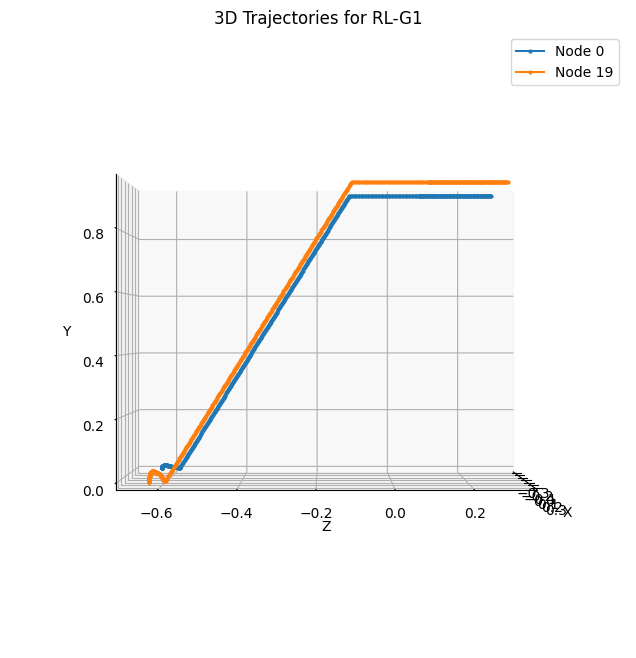

Running RL_G2
Based on your mesh, your best dt is: 0.002371335656962282


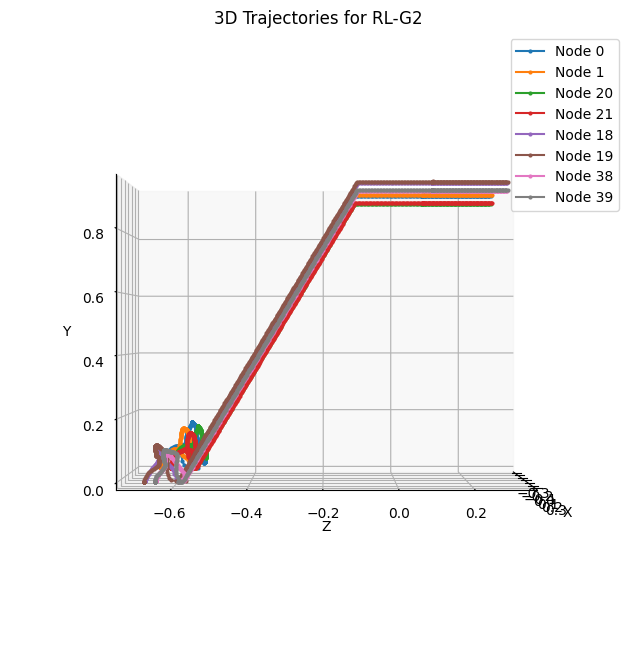

Running RL_G3
Based on your mesh, your best dt is: 0.002371335656962282


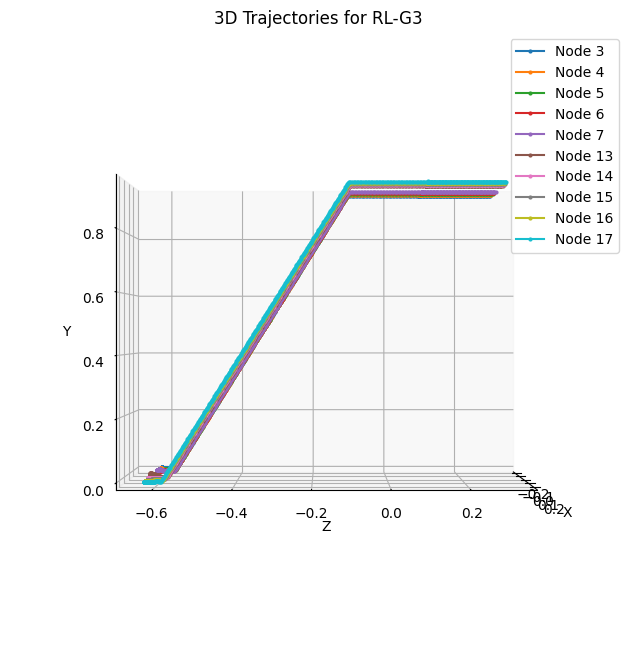

Running RL_G4
Based on your mesh, your best dt is: 0.002371335656962282


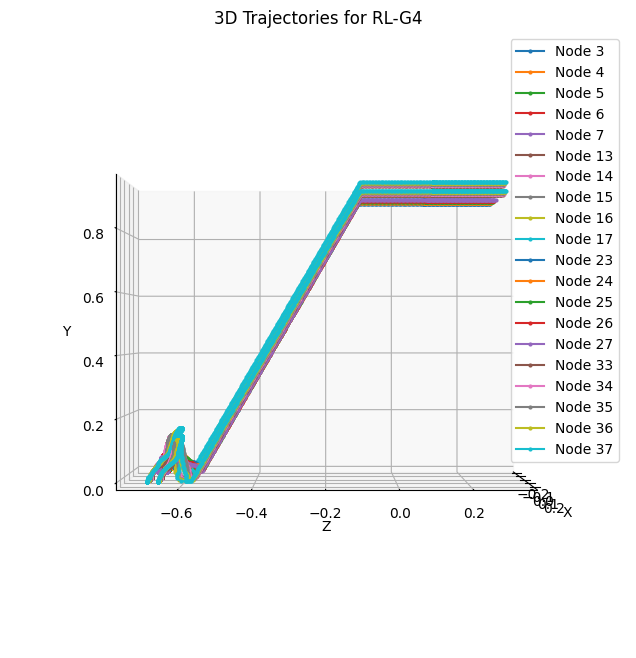

Running RL_G5
Based on your mesh, your best dt is: 0.002371335656962282


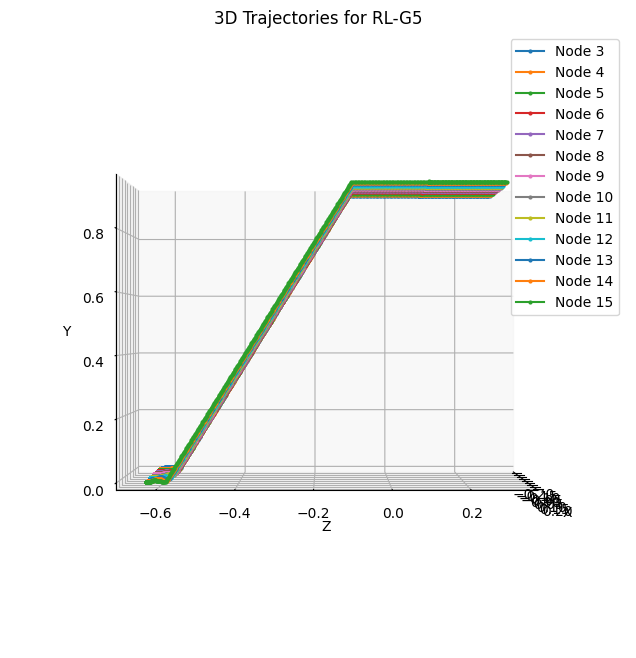

Running RL_G6
Based on your mesh, your best dt is: 0.002371335656962282


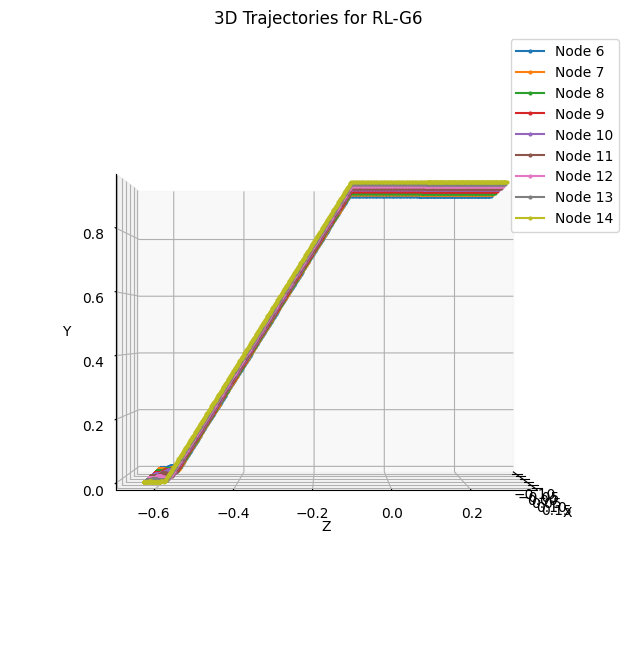

Running EL_G1
Based on your mesh, your best dt is: 0.002371335656962282


KeyboardInterrupt: 

: 

In [ ]:
import itertools
import os
import polyscope as ps

cloth_list = ["RL", "EL", "RH", "EH"] 
grasp_list = ["G1", "G2", "G3", "G4", "G5", "G6"]


for cloth_name, grasp_name in itertools.product(cloth_list, grasp_list):

    print(f"Running {cloth_name}_{grasp_name}")

    # Run simulation
    history, Am, label, faces = run_experiment(cloth_name, grasp_name)

    na = 20
    inds_ctr = get_grasp_config(grasp_name, na) # get controlled nodes

    # Plot 3D trajectory of nodes
    fig3D = plt.figure(figsize=(10, 8))
    ax = fig3D.add_subplot(111, projection='3d')

    # Camera view: adjusted to see it from the front
    ax.view_init(elev=50, azim=-45)

    for node_id in inds_ctr: # plot trajectory for each selected node
        trajectory = history[:, node_id, :] # get the history_pos of the nodes
        
        ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], label=f'Node {node_id}', marker='o', markersize=2) # plot XYZ given by (X, Z, Y)

    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_zlabel('Y')
    ax.legend()
    plt.title(f'3D Trajectories for {cloth_name}-{grasp_name}')
    plt.show()



#### Function to compute wrinkle metric

##### a) Function to compute the sigma, which indicates the wrinkle intensity

In [8]:
# before calling this function, we need to do 
# V = Am @ history[-1] -> reconstruction of the final position of the mesh with more resolution using Am

import numpy as np

def compute_wrinkle_sigma(V, k=20):
    """
    Compute surface variation (wrinkle intensity) per vertex.

    Parameters:
        V : (N,3) array of vertex positions
        k : number of nearest neighbors

    Returns:
        sigma : (N,) wrinkle intensity values
    """

    N = V.shape[0]
    sigma = np.zeros(N) # vector to store wrinkle intensity for each vertex

    for i in range(N): # loop over each vertex

        # Compute distances to all other points
        diff = V - V[i] # vector from v_i to all other vertices
        dist2 = np.sum(diff**2, axis=1) # squared Euclidean distancew

        # Get k nearest neighbors (excluding itself)
        idx = np.argsort(dist2)[1:k+1] # sort all distances and pick the k closest neighbors
        neighbors = V[idx]

        # Compute local mean to get centroid of neighborhood
        mean = np.mean(neighbors, axis=0)

        # Compute covariance matrix
        centered = neighbors - mean # center points around mean (shift neighbors to centroid)
        C = centered.T @ centered / k # covariance matrix of the neighborhood (3x3) captures local geometry around vertex i

        # Eigenvalues (symmetric matrix)
        eigvals = np.linalg.eigvalsh(C)
        # Sort them ascending 
        lambda1, lambda2, lambda3 = eigvals[2], eigvals[1], eigvals[0]

        # Surface variation = wrinkle intensity
        sigma[i] = lambda3 / (lambda1 + lambda2 + lambda3 + 1e-12)

    return sigma


#### Function for plotting of final meshes using sigma 

In [9]:
# Plotting of the final 3D mesh wrt wrinkle factor 
# using the global one to normalize the mapping

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# V = reconstructed vertices (n_vertices x 3)
# wrinkle_metric = numpy array of shape (n_vertices,), like global wrinkliness, curvature, deviation, etc.

def plot_wrinkle_metric(V, sigma, title, save_name=None):

    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')

    # Normalize metric for coloring
    # metric_norm = (sigma - sigma.min()) / (sigma.max() - sigma.min())
    """ Above, just colored-map based on the min and max of the metric, 
    but a few very large wrinkle values can dominate, so small wrinkles become almost invisible in the colormap.
    To solve it, instead of normalizing by the absolute min/max, 
    I normalize by the 1rst and 96th percentiles and ignores extreme outliers.
    Then, values below 1rst percentile are 0 and above 96th percentile are set to 1."""
    # low, high = np.percentile(sigma, [2, 96]) # can change percentiles to get more or less contrast in the colormap
    # metric_norm = np.clip((sigma - low) / (high - low), 0, 1)
    # global_max = 0.325
    # metric_norm = np.clip(sigma / global_max, 0, 1)

    GLOBAL_MIN = 0.0
    GLOBAL_MAX = 0.25   # choose based on worst experiment observed

    # Scatter plot with color
    p = ax.scatter(V[:,0], V[:,1], V[:,2], c=sigma, cmap='plasma', s=20, vmin=GLOBAL_MIN, vmax=GLOBAL_MAX)
    fig.colorbar(p, label='Wrinkle intensity $\sigma_i$')

    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_ylim(-0.7, 0.35)
    ax.set_zlabel('Y')
    ax.set_zlim(0, 0.7) 

    ax.set_proj_type('ortho')  # orthographic projection

    ax.view_init( # adjust to set view of the plot
        elev=25, # vertical angle, degrees above XY plane
        azim=-15)  # horizontal rotation, degrees around Z-axis (+ degrees is counterclockwise, so - for clockwise)
    ax.set_title(title)

    # save plot
    if save_name is not None:
        fig.savefig(save_name, dpi=300, bbox_inches='tight')
        print(f"Saved wrinkle plot: {save_name}")

    # plt.show()
    plt.close(fig)   # prevent it from displaying


#### Functions for Wrinkliness Metric with the wrinkled area

In [10]:
# compute areas around vertices

import numpy as np

def vertex_areas(V, F):
    """
    Compute approximate area around each vertex for a quad mesh.
    
    V: (n_verts, 3) vertex positions
    F: (n_faces, 4) quad faces (vertex indices)
    """
    areas = np.zeros(V.shape[0])
    
    # split quads into 2 triangles for area computation
    tris = np.vstack([F[:, [0,1,2]], F[:, [0,2,3]]])
    
    for tri in tris:
        v0, v1, v2 = V[tri[0]], V[tri[1]], V[tri[2]]
        tri_area = 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0))
        areas[tri] += tri_area / 3  # distribute equally to 3 vertices
        
    return areas

In [11]:
def compute_wrinkle_metric_area(V, F, sigma):
    areas = vertex_areas(V, F)
    
    # weighted mean
    W_global = np.sum(sigma * areas) / np.sum(areas)
    
    return W_global

#### Loop to automatically run experiment + compute metric + plot (saved)

In [12]:
# Loop to get plot + wrinkle metrics for experiments

import pandas as pd
import itertools

cloth_list = ["RH"] # add more cloth types ["RL", "EL", "RH", "EH", "M"] 
grasp_list = ["G1"] # add more grasp configurations ["G1", "G2", "G3", "G4", "G5", "G6"]

# Create empty dataframe with grasps as rows and cloth types as columns
results_df = pd.DataFrame(index=grasp_list, columns=cloth_list)

for cloth_name, grasp_name in itertools.product(cloth_list, grasp_list):
    # Run simulation
    history, Am, label, faces = run_experiment(cloth_name, grasp_name)

    V = Am @ history[-1]  # final cloth configuration with more resolution using Am

    sigma = compute_wrinkle_sigma(V, k=50)

    W_global = compute_wrinkle_metric_area(V, faces, sigma)

    # Store value in DataFrame
    results_df.loc[grasp_name, cloth_name] = W_global

    print(f"{label}")
    print("Global wrinkliness:", W_global)

    plot_wrinkle_metric(V, sigma, title=f"Wrinkle map for {cloth_name}_{grasp_name} - Global W: {W_global:.4f}", save_name=f"WrinkleMap_{cloth_name}_{grasp_name}.png")

    print(f"Finished for {cloth_name}_{grasp_name}")

# Save results to CSV
results_df.to_csv("wrinkle_metrics.csv")

Based on your mesh, your best dt is: 0.002371335656962282
[polyscope] Backend: openGL3_glfw -- Loaded openGL version: 4.1 INTEL-24.5.8
RH_G1
Global wrinkliness: 0.036012766321910875
Saved wrinkle plot: WrinkleMap_RH_G1.png
Finished for RH_G1


#### Correlation matrices

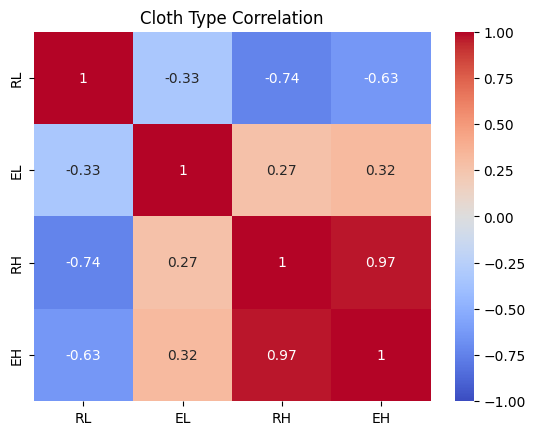

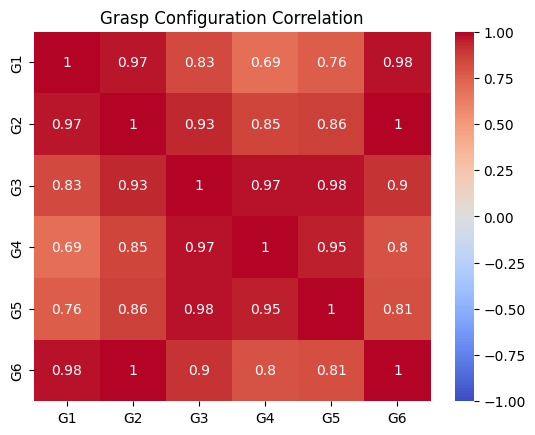

Saved correlation matrix: Cloth-Type Correlation Matrix.png
Saved correlation matrix: Grasp-Configuration Correlation Matrix.png


In [19]:
# Correlation matrix between cloth-types and grasp-types

import seaborn as sns
import matplotlib.pyplot as plt

# Correlation metrics
corr_cloth = results_df.astype(float).corr() # correlation for cloth
corr_grasp = results_df.astype(float).T.corr() # correlation for grasp (T because we want to correlate rows = grasps)

# Matrices
fig = plt.figure()
sns.heatmap(corr_cloth, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Cloth Type Correlation")
plt.show()

fig2 = plt.figure()
sns.heatmap(corr_grasp, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Grasp Configuration Correlation")
plt.show()

# save figures
save_name = f"Cloth-Type Correlation Matrix.png" 
fig.savefig(save_name, dpi=300, bbox_inches='tight')
print(f"Saved correlation matrix: {save_name}")

save_name2 = f"Grasp-Configuration Correlation Matrix.png" 
fig2.savefig(save_name2, dpi=300, bbox_inches='tight')
print(f"Saved correlation matrix: {save_name2}")


Saved figure


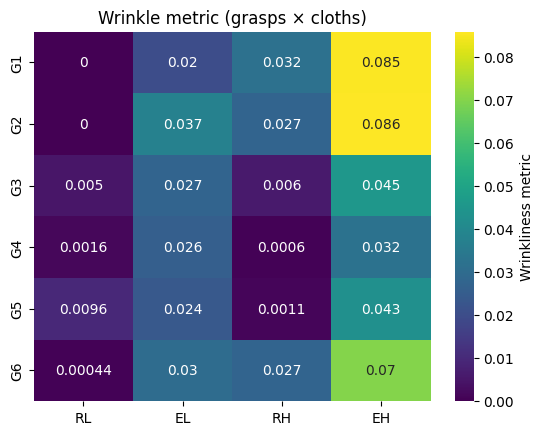

In [20]:
# Heatmap of the wrinkle metric values for each experiment (grasps as rows, cloths as columns)

import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure()
cbar = sns.heatmap(results_df.astype(float), annot=True, cmap="viridis").collections[0].colorbar
plt.title("Wrinkle metric (grasps × cloths)")
cbar.set_label("Wrinkliness metric")
fig.savefig("Wrinkle Matrix.png", dpi=300, bbox_inches="tight")
print(f"Saved figure")

#### Bar plot

In [22]:
# Bar plot for different cloth-types vs. grasps

import pandas as pd

data = []

# which ones to take on plots
cloth_list = ["RL", "EL", "RH", "EH"] # ["RL", "EL", "RH", "EH", "M", "L_Mid-E", "H_Mid-E", "R_H-Mid", "E_H-Mid"]

for cloth in cloth_list:
    for grasp in grasp_list:
        data.append({
            "cloth": cloth,
            "grasp": grasp,
            "wrinkle": results_df.loc[grasp, cloth]
        })

df_long = pd.DataFrame(data)

# classify cloths into 3 weights classes
df_long["weight"] = df_long["cloth"].map({
    "EL": "light",
    "RL": "light",
    "EH": "heavy",
    "RH": "heavy",
    # "M": "medium",
    # "R_H-Mid": "medium",
    # "E_H-Mid": "medium",
    # "L_Mid-E": "light", 
    # "H_Mid-E": "heavy"

})

# classify cloths into 3 elastic classes
df_long["elasticity"] = df_long["cloth"].map({
    "EL": "elastic",
    "RL": "rigid",
    "EH": "elastic",
    "RH": "rigid",
    # "M": "medium",
    # "R_H-Mid": "rigid",
    # "E_H-Mid": "elastic",
    # "L_Mid-E":"medium", 
    # "H_Mid-E": "medium"
})

# ranking of best grasps per cloth-type (rank 1 = best grasp w/ least wrinkling)
df_long["rank"] = df_long.groupby("cloth")["wrinkle"] \
                          .rank(method="min", ascending=True)

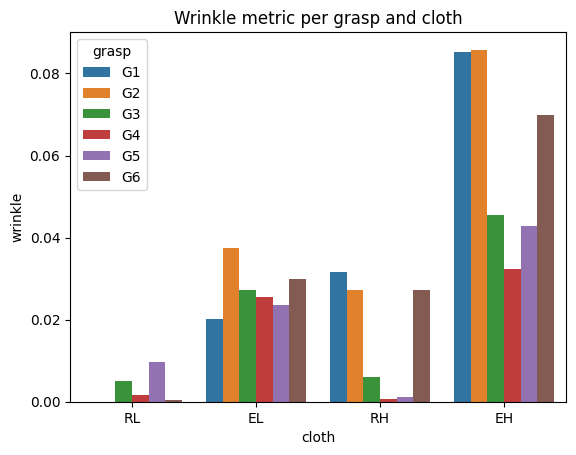

Saved plot: Bar Plot.png


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure()
sns.barplot(data=df_long, x="cloth", y="wrinkle", hue="grasp")
plt.title("Wrinkle metric per grasp and cloth")
plt.show()

# save figures
save_name = f"Bar Plot.png" 
fig.savefig(save_name, dpi=300, bbox_inches='tight')
print(f"Saved plot: {save_name}")

#### Correlation matrix about best grasp-type for each cloth-type

In [24]:
# construct the ranking matrix to do correlation

rank_matrix = df_long.pivot(index="grasp", 
                            columns="cloth", 
                            values="rank")

print(rank_matrix)

# correlation 
rank_corr = rank_matrix.corr()
print(rank_corr)

cloth   EH   EL   RH   RL
grasp                    
G1     5.0  1.0  6.0  1.0
G2     6.0  6.0  4.0  1.0
G3     3.0  4.0  3.0  5.0
G4     1.0  3.0  1.0  4.0
G5     2.0  2.0  2.0  6.0
G6     4.0  5.0  5.0  3.0
cloth        EH        EL        RH        RL
cloth                                        
EH     1.000000  0.371429  0.828571 -0.828079
EL     0.371429  1.000000  0.028571 -0.207020
RH     0.828571  0.028571  1.000000 -0.724569
RL    -0.828079 -0.207020 -0.724569  1.000000


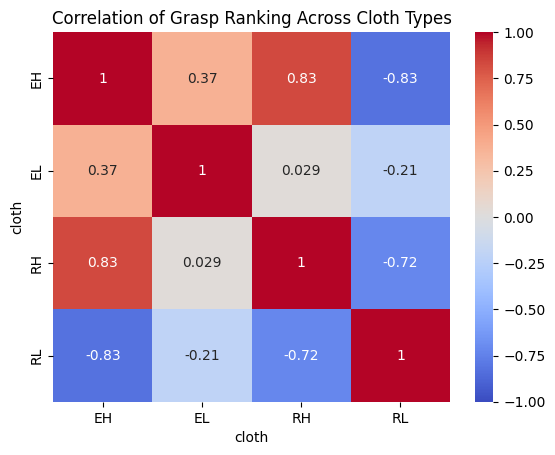

Saved plot: Correlation Matrix for Grasp Ranking.png


In [25]:
# draw correlation matrix

import seaborn as sns
import matplotlib.pyplot as plt

fig = plt.figure()
sns.heatmap(rank_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of Grasp Ranking Across Cloth Types")
plt.show()

# save figures
save_name = f"Correlation Matrix for Grasp Ranking.png" 
fig.savefig(save_name, dpi=300, bbox_inches='tight')
print(f"Saved plot: {save_name}")

In [26]:
# lowest mean means stable cloth (less wrinkle)

mean_wrinkle = df_long.groupby("cloth")["wrinkle"].mean()
print(mean_wrinkle)

cloth
EH    0.060247
EL    0.027299
RH    0.015643
RL    0.002769
Name: wrinkle, dtype: float64


Based on your mesh, your best dt is: 0.002371335656962282
RL_G1 -> W = 0.00000
Based on your mesh, your best dt is: 0.002371335656962282
RL_G2 -> W = 0.00000
Based on your mesh, your best dt is: 0.002371335656962282
RL_G3 -> W = 0.00498
Based on your mesh, your best dt is: 0.002371335656962282
RL_G4 -> W = 0.00158
Based on your mesh, your best dt is: 0.002371335656962282
RL_G5 -> W = 0.00962
Based on your mesh, your best dt is: 0.002371335656962282
RL_G6 -> W = 0.00044
Based on your mesh, your best dt is: 0.002371335656962282
EL_G1 -> W = 0.02008
Based on your mesh, your best dt is: 0.002371335656962282
EL_G2 -> W = 0.03746
Based on your mesh, your best dt is: 0.002371335656962282
EL_G3 -> W = 0.02717
Based on your mesh, your best dt is: 0.002371335656962282
EL_G4 -> W = 0.02563
Based on your mesh, your best dt is: 0.002371335656962282
EL_G5 -> W = 0.02351
Based on your mesh, your best dt is: 0.002371335656962282
EL_G6 -> W = 0.02996
Based on your mesh, your best dt is: 0.0023713356569

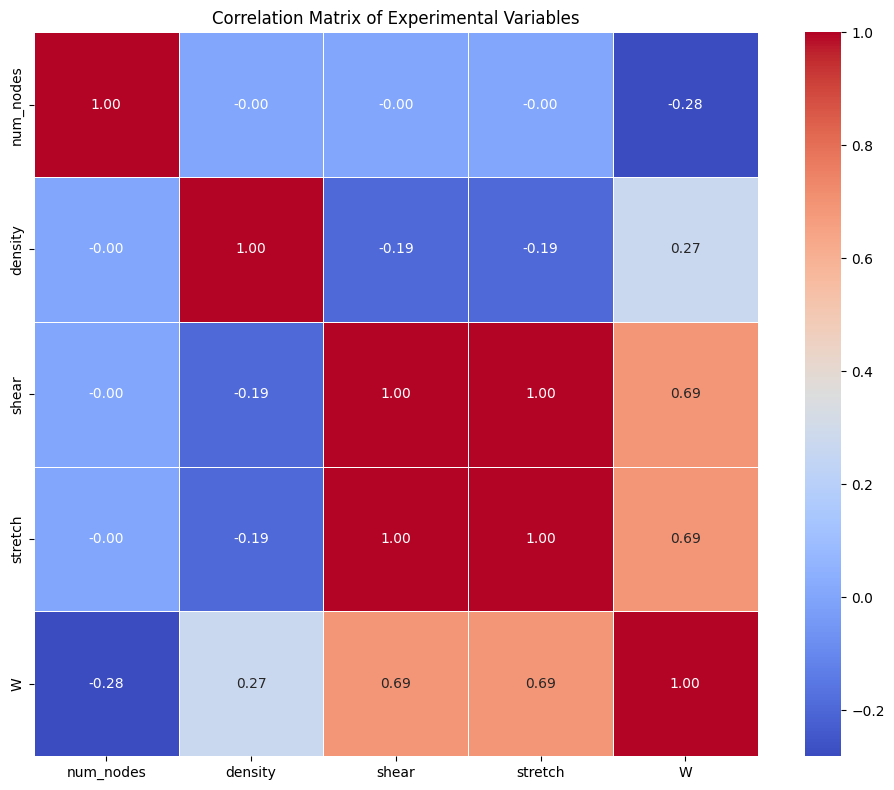


Correlation with Wrinkliness Metric W:

W            1.000000
stretch      0.693425
shear        0.693425
density      0.270048
num_nodes   -0.281086
Name: W, dtype: float64


In [ ]:
# ============================================================
# CORRELATION ANALYSIS BETWEEN:
# - Grasp characteristics
# - Cloth material properties
# - Wrinkliness metric W
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

# ============================================================
# 1. DEFINE EXPERIMENTAL VARIABLES
# ============================================================

# -----------------------------
# Grasp descriptors
# IMPORTANT:
# These are PHYSICAL descriptors,
# not just categorical labels.
# -----------------------------

grasp_features = {
    "G1": {
        "num_nodes": 2,
        "symmetric": 1,
        "bimanual": 1
    },
    "G2": {
        "num_nodes": 8,
        "symmetric": 1,
        "bimanual": 1
    },
    "G3": {
        "num_nodes": 10,
        "symmetric": 1,
        "bimanual": 1
    },
    "G4": {
        "num_nodes": 20,
        "symmetric": 1,
        "bimanual": 1
    },
    "G5": {
        "num_nodes": 12,
        "symmetric": 0,
        "bimanual": 0
    },
    "G6": {
        "num_nodes": 6,
        "symmetric": 0,
        "bimanual": 0
    }
}

# -----------------------------
# Cloth material descriptors
# -----------------------------

cloth_features = {
    "RL": {
        "density": 0.1,
        "shear": 0.1e-4,
        "stretch": 0.001e-4,
    },
    "EL": {
        "density": 0.1,
        "shear": 10e-4,
        "stretch": 0.1e-4,
    },
    "RH": {
        "density": 0.4,
        "shear": 0.1e-4,
        "stretch": 0.001e-4,
    },
    "EH": {
        "density": 0.3,
        "shear": 10e-4,
        "stretch": 0.1e-4,
    }
}

# ============================================================
# 2. BUILD DATASET
# ============================================================

rows = []

cloth_list = ["RL", "EL", "RH", "EH"]
grasp_list = ["G1", "G2", "G3", "G4", "G5", "G6"]

for cloth_name, grasp_name in itertools.product(cloth_list, grasp_list):

    # --------------------------------------------------------
    # RUN EXPERIMENT
    # --------------------------------------------------------

    history, Am, label, faces = run_experiment(cloth_name, grasp_name)

    V = Am @ history[-1]

    sigma = compute_wrinkle_sigma(V, k=50)

    W_global = compute_wrinkle_metric_area(V, faces, sigma)

    print(f"{cloth_name}_{grasp_name} -> W = {W_global:.5f}")

    # --------------------------------------------------------
    # BUILD ROW
    # --------------------------------------------------------

    row = {
        "cloth": cloth_name,
        "grasp": grasp_name,

        # ---- grasp features ----
        "num_nodes": grasp_features[grasp_name]["num_nodes"],

        # ---- cloth features ----
        "density": cloth_features[cloth_name]["density"],
        "shear": cloth_features[cloth_name]["shear"],
        "stretch": cloth_features[cloth_name]["stretch"],

        # ---- output metric ----
        "W": W_global
    }

    rows.append(row)

# ============================================================
# 3. CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(rows)

print(df.head())

# Save dataset
df.to_csv("experiment_dataset.csv", index=False)

# ============================================================
# 4. CORRELATION MATRIX
# ============================================================

# Keep only numerical columns
corr_df = df.select_dtypes(include=[np.number])

# Pearson correlation
corr_matrix = corr_df.corr(method="pearson")

print(corr_matrix)

# Save correlation matrix
corr_matrix.to_csv("correlation_matrix.csv")

# ============================================================
# 5. PLOT CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix of Experimental Variables")

plt.tight_layout()

plt.savefig("Correlation_Matrix.png", dpi=300)

plt.show()

# ============================================================
# 6. SORT CORRELATIONS WITH WRINKLINESS
# ============================================================

corr_with_W = corr_matrix["W"].sort_values(ascending=False)

print("\nCorrelation with Wrinkliness Metric W:\n")
print(corr_with_W)

# Optional: save
corr_with_W.to_csv("Correlation_With_W.csv")

----------------------------------------------

### Report Visuals

Plot of the initial meshes with the corresponding grasped nodes

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_mesh_with_grasp(X, T, inds_ctr, title="Mesh"):
    """
    Plots the 3D mesh with grasp points highlighted.
    
    Parameters:
    - X: (n,3) vertex positions
    - T: (m,3) triangle connectivity
    - inds_ctr: list of vertex indices to highlight (grasp points)
    - title: plot title
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Use Poly3DCollection for exact mesh triangles
    triangles = X[T]  # shape (m,3,3)
    mesh = Poly3DCollection(triangles, alpha=0.9, zorder=1)
    mesh.set_facecolor('lightblue')
    mesh.set_edgecolor('gray')
    mesh.set_linewidth(0.3)
    ax.add_collection3d(mesh)
    
    # Compute slight offset along Z to bring grasp points forward (in front of mesh)
    offset = -0.01  # small offset
    X_offset = X.copy()
    X_offset[inds_ctr, 1] += offset  # offset in Z! (not Y) -> need to set camera from front because if not, nodes look displaced
    
    ax.scatter(
        X_offset[inds_ctr, 0],
        X_offset[inds_ctr, 1],
        X_offset[inds_ctr, 2],
        color='red',
        s=10,
        depthshade=False
    )
    
    # Set equal aspect ratio
    ax.set_box_aspect([1,1,1])
    
    # Camera view: adjusted to see it from the front
    ax.view_init(elev=0, azim=-90)
    
    # Set axis labels consistent with your Y-up system
    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_zlabel('Y')
    
    # Optional: hide ticks for report-friendly figure
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylim(0,0.5)
    ax.set_zticks([])
    ax.grid(False)
    
    ax.set_title(title)
    plt.show()

    return fig # return figure to save it during the loop over the graspings

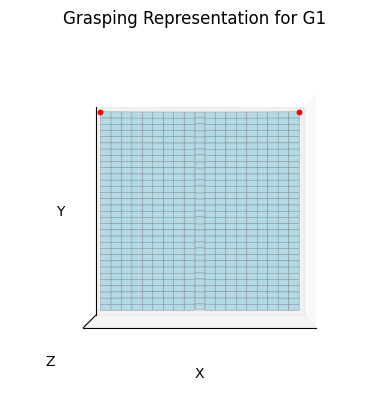

Saved wrinkle plot: Grasping Representation for G1


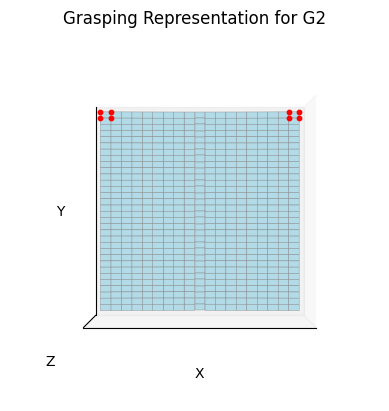

Saved wrinkle plot: Grasping Representation for G2


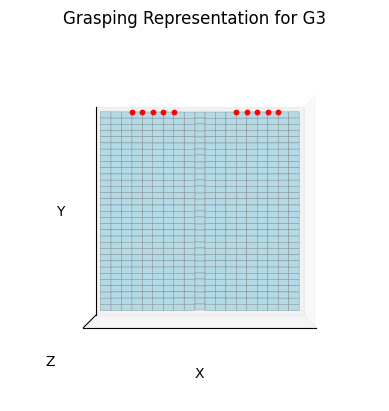

Saved wrinkle plot: Grasping Representation for G3


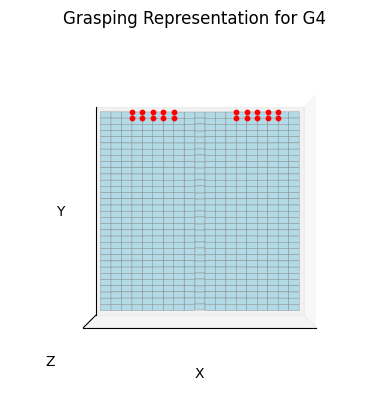

Saved wrinkle plot: Grasping Representation for G4


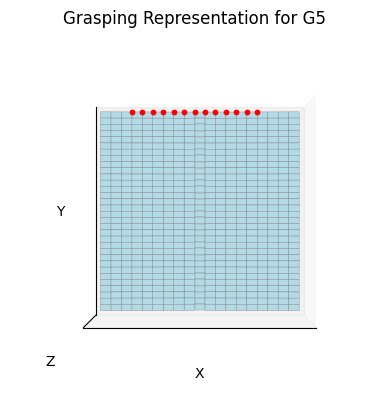

Saved wrinkle plot: Grasping Representation for G5


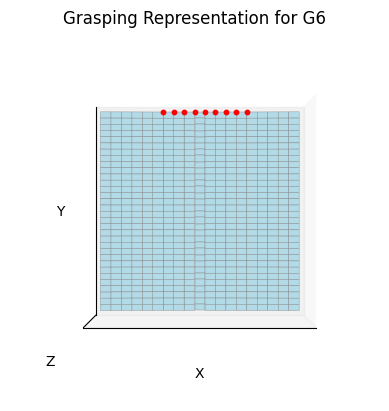

Saved wrinkle plot: Grasping Representation for G6


In [11]:
# Create mesh
X, T, na, nb = create_initial_mesh()

grasp_list = ["G1", "G2", "G3", "G4", "G5", "G6"]

for grasp_name in grasp_list:
    inds_ctr = get_grasp_config(grasp_name, na)
    fig = plot_mesh_with_grasp(X, T, inds_ctr, title=f"Grasping Representation for {grasp_name}")

    save_name = f"Grasping Representation for {grasp_name}"
    fig.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"Saved wrinkle plot: {save_name}")

Plot experimental trajectory

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_mesh_with_grasp_and_traj(X, T, inds_ctr, d=0.1, theta_deg=45, title="Mesh"):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # --- Mesh ---
    triangles = X[T]
    mesh = Poly3DCollection(triangles, alpha=0.45, zorder=1)
    mesh.set_facecolor('lightblue')
    mesh.set_edgecolor('none')
    mesh.set_linewidth(0.3)
    ax.add_collection3d(mesh)
    
    # --- Offset grasp points (visibility fix) ---
    offset = -0.01
    X_offset = X.copy()
    X_offset[inds_ctr, 1] += offset  # along Z
    
    ax.scatter(
        X_offset[inds_ctr, 0],
        X_offset[inds_ctr, 1],
        X_offset[inds_ctr, 2],
        color='red',
        s=10,
        depthshade=False
    )
    
    # =========================
    # 🚀 TRAJECTORIES (ALL NODES)
    # =========================
    
    theta = np.radians(theta_deg)
    
    dir_z = np.array([0.0, 1.0, 0.0])   # back-forth (Z)
    dir_y = np.array([0.0, 0.0, 1.0])  # down (Y)
    
    table_y = np.min(X[:,2])
    
    for idx in inds_ctr:
        p0 = X[idx].copy()
        
        # 1. backward
        p1 = p0 - d * dir_z
        
        # 2. forward
        # p2 = p1 + 2 * d * dir_z # 1rst baseline traj
        p2 = p1 + d/2 * dir_z # 2nd traj
        
        # 3. diagonal down
        h = p2[2] - table_y
        dz = abs(h) / np.tan(theta)
        dy = -h
        
        p3 = p2 + dz * dir_z + dy * dir_y
        
        # Apply same offset for visibility
        p0[1] += offset
        p1[1] += offset
        p2[1] += offset
        p3[1] += offset
        
        # --- Plot each phase with different color ---
        
        # Backward (red)
        ax.plot(
            [p0[0], p1[0]],
            [p0[1], p1[1]],
            [p0[2], p1[2]],
            color='red',
            linewidth=2
        )
        
        # Forward (green)
        ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            [p1[2], p2[2]],
            color='green',
            linewidth=1
        )
        
        # Downward diagonal (blue)
        ax.plot(
            [p2[0], p3[0]],
            [p2[1], p3[1]],
            [p2[2], p3[2]],
            color='blue',
            linewidth=1
        )
    
    # --- Formatting ---
    ax.set_box_aspect([1,1,1])
    ax.view_init(elev=30, azim=120)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_zlabel('Y')
    
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylim(0,0.5)
    ax.set_zticks([])
    ax.grid(False)

    ax.plot([], [], [], color='red', label='Backward')
    ax.plot([], [], [], color='green', label='Forward')
    ax.plot([], [], [], color='blue', label='Downward')
    ax.legend()
    
    ax.set_title(title)
    plt.show()

    return fig

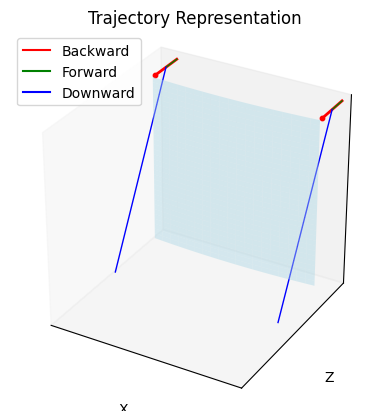

Saved: Grasping_Trajectory_II.png


In [66]:
X, T, na, nb = create_initial_mesh()

grasp_list = ["G1"] # only G1 for trajectory plotting

for grasp_name in grasp_list:
    inds_ctr = get_grasp_config(grasp_name, na)
    
    fig = plot_mesh_with_grasp_and_traj(
    X, T, inds_ctr,
    d=0.1,
    theta_deg=75,
    title=f"Trajectory Representation"
)

    save_name = f"Grasping_Trajectory_II.png"
    fig.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"Saved: {save_name}")

Plot orientation penalty representation

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_orientation_penalty(
    X_initial,
    X_final,
    T,
    node_top,
    node_bottom,
    title="Orientation Check"
):
    """
    Plot initial and final cloth configurations to illustrate
    the orientation penalty condition.

    Parameters
    ----------
    X_initial : (n,3)
        Initial mesh vertex positions.
    X_final : (n,3)
        Final mesh vertex positions.
    T : (m,3)
        Triangle connectivity.
    node_top : int
        Reference node initially considered 'top'.
    node_bottom : int
        Reference node initially considered 'bottom'.
    """

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')

    # ----------------------------
    # INITIAL MESH (transparent)
    # ----------------------------
    tri_init = X_initial[T]

    mesh_init = Poly3DCollection(
        tri_init,
        alpha=0.15,
        facecolor='gray',
        edgecolor='lightgray',
        linewidth=0.2
    )

    ax.add_collection3d(mesh_init)

    # ----------------------------
    # FINAL MESH
    # ----------------------------
    tri_final = X_final[T]

    mesh_final = Poly3DCollection(
        tri_final,
        alpha=0.9,
        facecolor='lightblue',
        edgecolor='gray',
        linewidth=0.3
    )

    ax.add_collection3d(mesh_final)

    # ----------------------------
    # REFERENCE NODES
    # ----------------------------

    # Initial positions
    ax.scatter(
        X_initial[node_top,0],
        X_initial[node_top,1],
        X_initial[node_top,2],
        color='green',
        s=60,
        alpha=0.3
    )

    ax.scatter(
        X_initial[node_bottom,0],
        X_initial[node_bottom,1],
        X_initial[node_bottom,2],
        color='red',
        s=60,
        alpha=0.3
    )

    # Final positions
    ax.scatter(
        X_final[node_top,0],
        X_final[node_top,1],
        X_final[node_top,2],
        color='green',
        s=100,
        label='Top reference node'
    )

    ax.scatter(
        X_final[node_bottom,0],
        X_final[node_bottom,1],
        X_final[node_bottom,2],
        color='red',
        s=100,
        label='Bottom reference node'
    )

    # ----------------------------
    # CHECK ORIENTATION
    # ----------------------------
    correct_orientation = (
        X_final[node_bottom,1] > X_final[node_top,1]
    )

    status = "Correct orientation" if correct_orientation else "Flipped orientation"

    # ----------------------------
    # VIEW SETTINGS
    # ----------------------------
    ax.set_box_aspect([1,1,1])

    ax.view_init(elev=15, azim=-30)

    ax.set_xlabel('X')
    ax.set_ylabel('Z')
    ax.set_zlabel('Y')

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    ax.grid(False)

    ax.set_title(f"{status}")

    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    return fig

In [72]:
def rotate_about_center(X, Rx):
    center = X.mean(axis=0)

    X_centered = X - center
    X_rotated = X_centered @ Rx.T

    return X_rotated + center

In [73]:
# Create mesh
X_initial, T, na, nb = create_initial_mesh()

# ------------------------
# GOOD ORIENTATION
# ------------------------
theta = np.pi / 2   # small rotation
Rx_good = np.array([
    [1, 0, 0],
    [0, np.cos(theta), -np.sin(theta)],
    [0, np.sin(theta),  np.cos(theta)]
])

X_final_good = rotate_about_center(X_initial, Rx_good)

# slight offset for visualization
X_final_good[:,1] -= 0.60
X_final_good[:,2] -= 0.45


# ------------------------
# FLIPPED ORIENTATION
# ------------------------
theta = -np.pi /2 # 180° flip
Rx_bad = np.array([
    [1, 0, 0],
    [0, np.cos(theta), -np.sin(theta)],
    [0, np.sin(theta),  np.cos(theta)]
])

X_final_flipped = rotate_about_center(X_initial, Rx_bad)

# slight offset for visualization
X_final_flipped[:,1] -= 0.60
X_final_flipped[:,2] -= 0.45

# slight offset
X_final_flipped[:,0] += 0.1

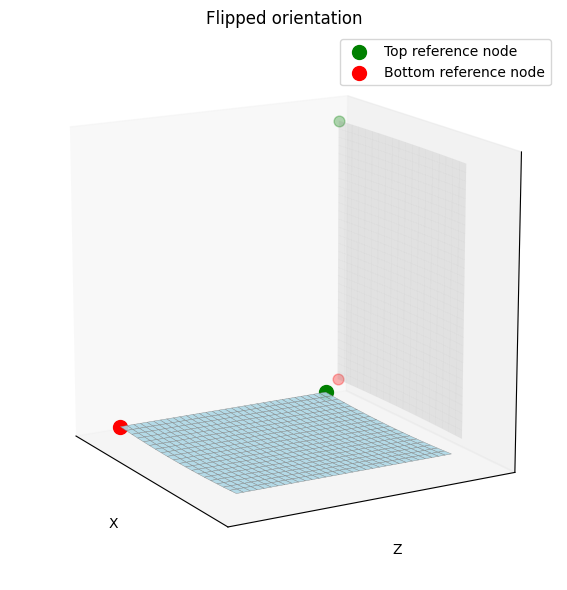

Saved: Bad_Orientation.png


In [75]:
# Plot orientations 

# # Good orientation
# fig = plot_orientation_penalty(
#     X_initial,
#     X_final_good,
#     T,
#     node_top=0,
#     node_bottom=(nb-1)*na,
#     title="Final configuration without penalty")

# Flipped orientation
fig = plot_orientation_penalty(
    X_initial,
    X_final_flipped,
    T,
    node_top=0,
    node_bottom=(nb-1)*na,
    title="Final configuration triggering orientation penalty")

save_name = f"Bad_Orientation.png"
fig.savefig(save_name, dpi=300, bbox_inches='tight')
print(f"Saved: {save_name}")